# Image downscaling

In [ ]:
import numpy as np
from PIL import Image
import os
from glob import glob
from tqdm.notebook import tqdm

def downscale(image : Image, size):
    image.thumbnail((size, size), Image.ANTIALIAS)
    return image

def crop(image : Image, size : int):
    width, height = image.size
    
    left = (width - size) / 2
    top = (height - size) / 2
    right = (width + size) / 2
    bottom = (height + size) / 2
    
    return image.crop((left, top, right, bottom))


os.mkdir("../Step 2 - Image dataset/Images/GZ12_All_Resized")

image_paths = glob("../Step 2 - Image dataset/Images/GZ12_All/*.jpg")

for image_path in tqdm(image_paths):
    if not os.path.exists(f"../Step 2 - Image dataset/Images/GZ12_All_Resized/{os.path.basename(image_path)}"):
        img = Image.open(image_path)
        img = crop(img, 224)
        img = downscale(img, 128)

        img.save(f"../Step 2 - Image dataset/Images/GZ12_All_Resized/{os.path.basename(image_path)}")

# =====================
# GZC
# =====================

# os.mkdir("../Step 2 - Image dataset/Images/GZC_Resized")

# image_paths = glob("../Step 2 - Image dataset/Images/GZC/images/*.jpg")

# for image_path in tqdm(image_paths):
#     if not os.path.exists(f"../Step 2 - Image dataset/Images/GZC_Resized/{os.path.basename(image_path)}"):
#         img = Image.open(image_path)
#         img = crop(img, 224)
#         img = downscale(img, 128)

#         img.save(f"../Step 2 - Image dataset/Images/GZC_Resized/{os.path.basename(image_path)}")

# =====================
# GZD
# =====================

# os.mkdir("../Step 2 - Image dataset/Images/GZD_Resized")

# image_paths = glob("../Step 2 - Image dataset/Images/GZD/images/*/*.jpg")

# for image_path in tqdm(image_paths):
#     if not os.path.exists(f"../Step 2 - Image dataset/Images/GZD_Resized/{os.path.basename(image_path)}"):
#         img = Image.open(image_path)
#         img = crop(img, 224)
#         img = downscale(img, 128)

#         img.save(f"../Step 2 - Image dataset/Images/GZD_Resized/{os.path.basename(image_path)}")

# =====================
# GZH
# =====================

# os.mkdir("../Step 2 - Image dataset/Images/GZH_Resized")

# image_paths = glob("../Step 2 - Image dataset/Images/GZH/images/*.jpg")

# for image_path in tqdm(image_paths):
#     if not os.path.exists(f"../Step 2 - Image dataset/Images/GZH_Resized/{os.path.basename(image_path)}"):
#         img = Image.open(image_path)
#         img = crop(img, 224)
#         img = downscale(img, 128)

#         img.save(f"../Step 2 - Image dataset/Images/GZH_Resized/{os.path.basename(image_path)}")



# Final image dataset creation

In [ ]:
# Export FinalDataset to csv

import pandas as pd
import os
from PIL import Image
from tqdm.notebook import tqdm

image_path = '../Step 2 - Image dataset/Images'

dataset_path = 'Images/AllClasses'

if not os.path.exists(f"./{dataset_path}"):
    os.mkdir(f"./{dataset_path}") 

dataset = pd.read_csv("./FinalDataset_2Class_New.csv", dtype={
    "GZ1_Id": "string",
    "GZ2_Id": "string",
    "GZH_Id": "string",
    "GZC_Id": "string",
    "GZD12_Id": "string",
    "GZD5_Id": "string",
    'OriginalDatasetId': "string"})

# dataset = dataset.rename(columns={
#     "Coordinates_GZ1_Id": "GZ1_Id",
#     "Coordinates_GZ2_Id": "GZ2_Id",
#     "Coordinates_GZC_Id": "GZC_Id",
#     "Coordinates_GZH_Id": "GZH_Id",
#     "Coordinates_GZD12_Id": "GZD12_Id",
#     "Coordinates_GZD5_Id": "GZD5_Id",
#     })

gzh_dataset = pd.read_csv("../Step 1 - Database/GZH/gz_hubble_main.csv")

empty_galaxy_count = 0

for _, row in tqdm(dataset.iterrows(), total = len(dataset)):
    written = False

    if os.path.exists(f"{dataset_path}/{row['Id']}"):
        continue

    if not os.path.exists(f"{dataset_path}/{row['Id']}"):
        os.mkdir(f"{dataset_path}/{row['Id']}")

    if not pd.isna(row["GZ1_Id"]):
        if os.path.exists(f"{image_path}/GZ12_All_Resized/{row['GZ1_Id']}.jpg") and not os.path.exists(f"{dataset_path}/{row['Id']}/{row['GZ1_Id']}.jpg"):
            gz12_img = Image.open(f"{image_path}/GZ12_All_Resized/{row['GZ1_Id']}.jpg")
            gz12_img.save(f"{dataset_path}/{row['Id']}/{row['GZ1_Id']}.jpg")
            written = True
    
    if not pd.isna(row["GZ2_Id"]):
        if os.path.exists(f"{image_path}/GZ12_All_Resized/{row['GZ2_Id']}.jpg") and not os.path.exists(f"{dataset_path}/{row['Id']}/{row['GZ2_Id']}.jpg"):
            gz12_img = Image.open(f"{image_path}/GZ12_All_Resized/{row['GZ2_Id']}.jpg")
            gz12_img.save(f"{dataset_path}/{row['Id']}/{row['GZ2_Id']}.jpg")
            written = True

    if not pd.isna(row["GZH_Id"]):
        gzh_id = gzh_dataset[gzh_dataset["zooniverse_id"] == row["GZH_Id"]]["survey_id"].iloc[0]
        if os.path.exists(f"{image_path}/GZH_Resized/{gzh_id}.jpg"):
            gzh_img = Image.open(f"{image_path}/GZH_Resized/{gzh_id}.jpg")
            gzh_img.save(f"{dataset_path}/{row['Id']}/{row['GZH_Id']}.jpg") # save as original id to match db naming
            written = True

    if not pd.isna(row["GZC_Id"]) and os.path.exists(f"{image_path}/GZC_Resized/{row['GZC_Id']}.jpg"):
        gzc_img = Image.open(f"{image_path}/GZC_Resized/{row['GZC_Id']}.jpg")
        gzc_img.save(f"{dataset_path}/{row['Id']}/{row['GZC_Id']}.jpg")
        written = True

    if not pd.isna(row["GZD12_Id"]) and os.path.exists(f"{image_path}/GZD_Resized/{row['GZD12_Id']}.jpg") and not os.path.exists(f"{dataset_path}/{row['Id']}/{row['GZD12_Id']}.jpg"):
        gzd_img = Image.open(f"{image_path}/GZD_Resized/{row['GZD12_Id']}.jpg")
        gzd_img.save(f"{dataset_path}/{row['Id']}/{row['GZD12_Id']}.jpg")
        written = True
    
    if not pd.isna(row["GZD5_Id"]) and os.path.exists(f"{image_path}/GZD_Resized/{row['GZD5_Id']}.jpg") and not os.path.exists(f"{dataset_path}/{row['Id']}/{row['GZD5_Id']}.jpg"):
        gzd_img = Image.open(f"{image_path}/GZD_Resized/{row['GZD5_Id']}.jpg")
        gzd_img.save(f"{dataset_path}/{row['Id']}/{row['GZD5_Id']}.jpg")
        written = True

    if not written:
        empty_galaxy_count = empty_galaxy_count + 1

print(empty_galaxy_count)

# TF Datasets

In [4]:
import tensorflow as tf
from tqdm.notebook import tqdm

IMAGE_SIZE = 128 #@param
CLASSES = [b'Elliptical', b'Spiral']
AUTO = tf.data.experimental.AUTOTUNE

def decode_jpeg_and_label(item):
  filename = item['image_path']
  galaxy_class = item['class']
  objid = item['objid']
  
  bits = tf.io.read_file(filename)
  image = tf.image.decode_jpeg(bits)
  return image, galaxy_class, objid

def recompress_image(image, label, objid):
  image = tf.image.encode_jpeg(image, optimize_size=True, chroma_downsampling=False)
  return image, label, objid

def _bytestring_feature(list_of_bytestrings):
  return tf.train.Feature(bytes_list=tf.train.BytesList(value=list_of_bytestrings))

def _int_feature(list_of_ints): # int64
  return tf.train.Feature(int64_list=tf.train.Int64List(value=list_of_ints))

def _float_feature(list_of_floats): # float32
  return tf.train.Feature(float_list=tf.train.FloatList(value=list_of_floats))

def to_tfrecord(tfrec_filewriter, img_bytes, bin, objid):  
  class_num = bin - 1
  # one_hot_class = np.eye(len(CLASSES))[class_num]     # [0, 0, 1, 0, 0] for class #2, roses

  feature = {
      "image": _bytestring_feature([img_bytes]), # one image in the list
      "class": _int_feature([class_num]),        # one class in the list
      
      # "label":         _bytestring_feature([CLASSES[class_num]]),          # fixed length (1) list of strings, the text label
      "objid":         _bytestring_feature([objid]),          # fixed length (1) list of strings, the text label
      # "one_hot_class": _float_feature(one_hot_class.tolist()) # variable length  list of floats, n=len(CLASSES)
  }
  return tf.train.Example(features=tf.train.Features(feature=feature))

def create_tf_record_dataset(filenames, items_per_record, output_folder):
  dataset2 = filenames.map(decode_jpeg_and_label, num_parallel_calls=AUTO)
  dataset3 = dataset2.map(recompress_image, num_parallel_calls=AUTO)
  dataset3 = dataset3.batch(items_per_record) # sharding: there will be one "batch" of images per file

  for shard, (image, bin, objid) in tqdm(enumerate(dataset3)):
    # batch size used as shard size here
    shard_size = image.numpy().shape[0]
    filename = output_folder + "/{:02d}-{}.tfrec".format(shard, shard_size)
    
    np_image = image.numpy()
    np_bin = bin.numpy()
    np_objid = objid.numpy()

    with tf.io.TFRecordWriter(filename) as out_file:
      for i in range(shard_size):
        example = to_tfrecord(out_file,
                              np_image[i], # re-compressed image: already a byte string
                              np_bin[i],
                              np_objid[i])
        out_file.write(example.SerializeToString())


In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
import tensorflow as tf
import pandas as pd
import os
import math


ids_to_path = lambda ids: np.array([f"Images/AllClasses/{row[0]}/{row[1]}.jpg" for row in ids])

def convert_ids_and_classes_to_dataset(ids, classes):
    dataset_dictionary = {
        "image_path": ids_to_path(ids),
        "class": classes.T,
        "objid": ids[:, 0].T.astype(str)
    }

    return tf.data.Dataset.from_tensor_slices(dataset_dictionary)



STRATEGY = 'MonteCarloCrossValidation'
BATCH_SIZE = 1024
N_CLASSES = 2

print("Loading dataset")

dataset = pd.read_csv(f"./FinalDataset_{N_CLASSES}Class_New.csv", dtype={
    "GZ1_Id": "string",
    "GZ2_Id": "string",
    "GZH_Id": "string",
    "GZC_Id": "string",
    "GZD12_Id": "string",
    "GZD5_Id": "string",
    'OriginalDatasetId': "string"})

filtered = dataset # filter if needed
filtered["OriginalImageExists"] = filtered.apply(lambda row: os.path.exists(f"Images/AllClasses/{row['Id']}/{row['OriginalDatasetId']}.jpg"), axis= 1)

galaxies = filtered[filtered["OriginalImageExists"]]

if STRATEGY == 'NFoldCrossValidation':

    print("K-fold cross-validation")

    N_FOLDS = 10
    SEED = 17

    kfold = StratifiedKFold(n_splits = N_FOLDS, shuffle = True, random_state = SEED)

    np.random.seed(SEED)

    if not os.path.exists(f"TFDataset"):
        os.mkdir(f"TFDataset") 

    if not os.path.exists(f"TFDataset/{N_FOLDS}_folds"):
        os.mkdir(f"TFDataset/{N_FOLDS}_folds") 

    fold = 1
    for train_index, test_index in kfold.split(galaxies[["Id", "OriginalDatasetId"]], galaxies[f"SpiralGalaxyCertaintyBucket_{N_CLASSES}Class"] ):
        print("fold", fold)

        if not os.path.exists(f"TFDataset/{N_FOLDS}_folds/fold_{fold}/train"):
            os.makedirs(f"TFDataset/{N_FOLDS}_folds/fold_{fold}/train") 
            os.makedirs(f"TFDataset/{N_FOLDS}_folds/fold_{fold}/test") 

        number_of_galaxies_to_pad = BATCH_SIZE - len(train_index) % BATCH_SIZE

        resample_indexes = np.random.choice(
            np.arange(len(train_index)),
            number_of_galaxies_to_pad,
            replace=False)

        original_train_ids = galaxies[["Id", "OriginalDatasetId"]].iloc[train_index]
        original_train_classes = galaxies[f"SpiralGalaxyCertaintyBucket_{N_CLASSES}Class"].iloc[train_index]

        padded_train_ids = np.concatenate((original_train_ids, original_train_ids.iloc[resample_indexes]))
        padded_train_classes = np.concatenate((original_train_classes, original_train_classes.iloc[resample_indexes]))

        test_ids = galaxies[["Id", "OriginalDatasetId"]].iloc[test_index]
        test_classes = galaxies[f"SpiralGalaxyCertaintyBucket_{N_CLASSES}Class"].iloc[test_index]

        tf_dataset = convert_ids_and_classes_to_dataset(padded_train_ids, padded_train_classes)
        create_tf_record_dataset(tf_dataset, 4096, f'TFDataset/{N_FOLDS}_folds/fold_{fold}/train')

        tf_dataset = convert_ids_and_classes_to_dataset(galaxies[["Id", "OriginalDatasetId"]].iloc[test_index].to_numpy(),  galaxies[f"SpiralGalaxyCertaintyBucket_{N_CLASSES}Class"].iloc[test_index].to_numpy())
        create_tf_record_dataset(tf_dataset, 4096, f'TFDataset/{N_FOLDS}_folds/fold_{fold}/test')

        fold += 1
elif STRATEGY == 'MonteCarloCrossValidation':

    SEED = 17
    N_FOLDS = 10

    for N_CLASSES in [5]:

        print("filtered")
        if not os.path.exists(f"TFDataset/MCCV/{N_CLASSES}_Classes/AllGalaxies"):
            os.makedirs(f"TFDataset/MCCV/{N_CLASSES}_Classes/AllGalaxies")
            create_tf_record_dataset(
                convert_ids_and_classes_to_dataset(galaxies[["Id", "OriginalDatasetId"]].to_numpy(),  galaxies[f"SpiralGalaxyCertaintyBucket_{N_CLASSES}Class"].to_numpy()),
                8192,
                f"TFDataset/MCCV/{N_CLASSES}_Classes/AllGalaxies")

        # for training_split in [10 ** (-2 - (1.0/3))]:
        for training_split in np.round(np.logspace(-2, 0, num=7)[:-1], 2):
            for fold in range(1, N_FOLDS + 1):
                print(f"{N_CLASSES} classes, {training_split}, {fold} fold")

                folder_base = f"TFDataset/MCCV/{N_CLASSES}_Classes/{round(training_split * 100):0>2}-{round((1-training_split) * 100):0>2}"
                if not os.path.exists(f"{folder_base}/fold_{fold}/train"):
                    os.makedirs(f"{folder_base}/fold_{fold}/train") 
                    os.makedirs(f"{folder_base}/fold_{fold}/test") 

                training_galaxies = galaxies.sample(frac=training_split, replace=False, random_state=SEED + fold)

                number_of_galaxies_to_pad = BATCH_SIZE - len(training_galaxies) % BATCH_SIZE

                resampled_galaxies = training_galaxies.sample(
                    n=number_of_galaxies_to_pad,
                    replace=False)

                padded_train_ids = np.concatenate((training_galaxies[["Id", "OriginalDatasetId"]], resampled_galaxies[["Id", "OriginalDatasetId"]]))
                padded_train_classes = np.concatenate((training_galaxies[f"SpiralGalaxyCertaintyBucket_{N_CLASSES}Class"], resampled_galaxies[f"SpiralGalaxyCertaintyBucket_{N_CLASSES}Class"]))

                test_galaxies = galaxies[~(galaxies["Id"].isin(training_galaxies["Id"]))]
                test_galaxies["Id"].to_csv(f'{folder_base}/fold_{fold}/test/galaxies.csv')
                print("done")
                # values, counts = np.unique(padded_train_classes, return_counts=True)
                # tf_dataset = convert_ids_and_classes_to_dataset(padded_train_ids, padded_train_classes)
                # print(values, counts)
                # create_tf_record_dataset(tf_dataset, 4096, f'{folder_base}/fold_{fold}/train')

                # tf_dataset = convert_ids_and_classes_to_dataset(test_galaxies[["Id", "OriginalDatasetId"]].to_numpy(),  test_galaxies[f"SpiralGalaxyCertaintyBucket_{N_CLASSES}Class"].to_numpy())
                # create_tf_record_dataset(tf_dataset, 4096, f'{folder_base}/fold_{fold}/test')

                # if fold == 1:
                #     f = open(f"{folder_base}/size.txt", "w")
                #     f.write(f"{{train: {len(padded_train_ids)}, test: {len(test_galaxies)}}}")
                #     f.close()


elif STRATEGY == 'TrainTestValidation':
    print('TrainTestValidation')
    SEED = 17

    for N_CLASSES in [3, 5]:
        dataset = pd.read_csv(f"./FinalDataset_{N_CLASSES}Class_New.csv", dtype={
            "GZ1_Id": "string",
            "GZ2_Id": "string",
            "GZH_Id": "string",
            "GZC_Id": "string",
            "GZD12_Id": "string",
            "GZD5_Id": "string",
                'OriginalDatasetId': "string"})

        filtered = dataset # filter if needed
        filtered["OriginalImageExists"] = filtered.apply(lambda row: os.path.exists(f"Images/AllClasses/{row['Id']}/{row['OriginalDatasetId']}.jpg"), axis= 1)

        galaxies = filtered[filtered["OriginalImageExists"]]

        

        for training_split in [2048, 4096, 8192, 16384]:

            folder_base = f"TFDataset/TrainTestValidation/{N_CLASSES}_Classes/{int(training_split)}"

            os.makedirs(f"{folder_base}/train", exist_ok=True)
            os.makedirs(f"{folder_base}/test", exist_ok=True)
            os.makedirs(f"{folder_base}/validation", exist_ok=True)

            test_split = int(training_split / 4) # 80-20

            training_galaxies = galaxies.sample(n=training_split, replace=False, random_state= SEED)

            test_validation_galaxies = galaxies[~(galaxies["Id"].isin(training_galaxies["Id"]))]

            test_galaxies = test_validation_galaxies.sample(n=test_split, replace=False, random_state= SEED)

            validation_galaxies = test_validation_galaxies[~(test_validation_galaxies["Id"].isin(test_galaxies["Id"]))]

            tf_dataset = convert_ids_and_classes_to_dataset(training_galaxies[["Id", "OriginalDatasetId"]].to_numpy(),  training_galaxies[f"SpiralGalaxyCertaintyBucket_{N_CLASSES}Class"].to_numpy())
            create_tf_record_dataset(tf_dataset, 4096, f'{folder_base}/train')

            tf_dataset = convert_ids_and_classes_to_dataset(test_galaxies[["Id", "OriginalDatasetId"]].to_numpy(),  test_galaxies[f"SpiralGalaxyCertaintyBucket_{N_CLASSES}Class"].to_numpy())
            create_tf_record_dataset(tf_dataset, 4096, f'{folder_base}/test')

            tf_dataset = convert_ids_and_classes_to_dataset(validation_galaxies[["Id", "OriginalDatasetId"]].to_numpy(),  validation_galaxies[f"SpiralGalaxyCertaintyBucket_{N_CLASSES}Class"].to_numpy())
            create_tf_record_dataset(tf_dataset, 4096, f'{folder_base}/validation')

In [32]:
import pandas as pd
import os


dataset = pd.read_csv(f"./FinalDataset_5Class_New.csv", dtype={
    "GZ1_Id": "string",
    "GZ2_Id": "string",
    "GZH_Id": "string",
    "GZC_Id": "string",
    "GZD12_Id": "string",
    "GZD5_Id": "string",
        'OriginalDatasetId': "string"})

filtered = dataset # filter if needed
filtered["OriginalImageExists"] = filtered.apply(lambda row: os.path.exists(f"Images/AllClasses/{row['Id']}/{row['OriginalDatasetId']}.jpg"), axis= 1)

galaxies = filtered[filtered["OriginalImageExists"]]
galaxies

,Id,OriginalDataset,OriginalDatasetId,GZ1_Id,GZ2_Id,GZH_Id,GZC_Id,GZD12_Id,GZD5_Id,ra,...,GZ2_5Class_Bin,GZC_5Class_Bin,GZH_5Class_Bin,GZD12_5Class_Bin,GZD5_5Class_Bin,Spec_z,Spec_z_err,SpiralGalaxyCertainty,SpiralGalaxyCertaintyBucket_5Class,OriginalImageExists
0,f00adc70-2315-4bb4-8b3b-2d19e7778c1e,GZ1,587731890040012914,587731890040012914,<NA>,<NA>,<NA>,<NA>,<NA>,174.789219,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.337209,2,True
1,0ca58154-81c6-4205-a3fd-c9e47aed96ca,GZ1,587732772128752011,587732772128752011,<NA>,<NA>,<NA>,<NA>,<NA>,181.299857,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.041112,1,True
2,0ca6a51e-fb0c-407f-80ca-02b354469a23,GZ1,587741821066412232,587741821066412232,<NA>,<NA>,<NA>,<NA>,<NA>,151.763945,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.113514,1,True
3,f00b09e0-3d88-44c8-a4bb-beac5962cb3e,GZ1,587731870171332762,587731870171332762,<NA>,<NA>,<NA>,<NA>,<NA>,181.348067,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.825607,5,True
4,0ca9ca3e-21cd-4b46-a6db-5d92323a013f,GZ1,587733079743725659,587733079743725659,<NA>,<NA>,<NA>,<NA>,<NA>,201.734010,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.384365,2,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737556,0c9be7ef-997e-4a95-8298-37dc9f28f7d7,GZ1,587732592252944624,587732592252944624,<NA>,<NA>,<NA>,<NA>,<NA>,184.532451,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.087571,1,True
737557,0c9c72f6-7c48-43e2-9426-3eab9f3a9ae7,GZ1,588018055668040272,588018055668040272,<NA>,<NA>,<NA>,<NA>,<NA>,256.045223,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.974000,5,True
737558,0c9f9cdb-aec4-4090-a521-9d6bb5200123,GZ1,587727179536859247,587727179536859247,<NA>,<NA>,<NA>,<NA>,<NA>,31.588906,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.850575,5,True
737559,0ca3d7ac-250f-4c66-b600-976343867dd9,GZ1,587732771591225489,587732771591225489,<NA>,<NA>,<NA>,<NA>,<NA>,179.834264,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.231405,2,True


In [ ]:
ids = ["2a6ca1cc-e716-45fb-b0ea-a77eaf62289e", "99188708-15ea-49f1-8ff5-803b70676f86", "19d1b907-f4d1-4918-a619-ab9a9ff5cb92", "d753d118-2c7b-4ff8-8ca1-cc21e7ee5927", "12b2d669-31a7-47fd-85a8-3c260674979f"]

chosen = galaxies[galaxies["Id"].isin(ids)][["Id", "OriginalDatasetId", "SpiralGalaxyCertainty"]].sort_values(by=["SpiralGalaxyCertainty"])
chosen

def show_image(row):
   plt.figure(figsize=(6, 6))
   plt.imshow(Image.open(f"Images/AllClasses/{row['Id']}/{row['OriginalDatasetId']}.jpg"))
   plt.xticks([])
   plt.yticks([])
   plt.xlabel(f"$SCI = {row['SpiralGalaxyCertainty']:.2f}$", fontsize=36, fontweight="bold")
   plt.tight_layout()
   plt.savefig(f"sci_{int(row['SpiralGalaxyCertainty'] / 0.2)}.pdf", dpi = 300)

for index, row in chosen.iterrows():
    show_image(row)

# for index, row in df.iterrows():
#     print(row['Id'], row['OriginalDatasetId'])
#     show_image(row)
# import matplotlib.pyplot as plt
# from PIL import Image

# #1
# plt.imshow(Image.open("Images/AllClasses/2a6ca1cc-e716-45fb-b0ea-a77eaf62289e/587726014013964512.jpg"))
# plt.xticks([])
# plt.yticks([])
# plt.xlabel("Certain Elliptical ($SCI = 0.113$)")
# plt.show()
# #2
# plt.imshow(Image.open("Images/AllClasses/c9b4a092-4fdc-4eec-8c25-2626d5350f47/587742190972698781.jpg"))
# plt.xticks([])
# plt.yticks([])
# plt.xlabel("Uncertain Elliptical ($SCI = 0.2$)")
# plt.show()

# #3
# plt.imshow(Image.open("Images/AllClasses/99c0de03-4ecc-45f7-98d6-9197e0c00fa2/588010880367657098.jpg"))
# plt.show()


# #4
# plt.imshow(Image.open("Images/AllClasses/340af7e6-79a9-4c2b-bb81-54f05a885a8f/587739607559241828.jpg"))
# plt.show()

# #5
# plt.imshow(Image.open("Images/AllClasses/a6d8f929-37fc-464d-974d-eef2f1357fbc/587738574073430146.jpg"))
# plt.show()
	

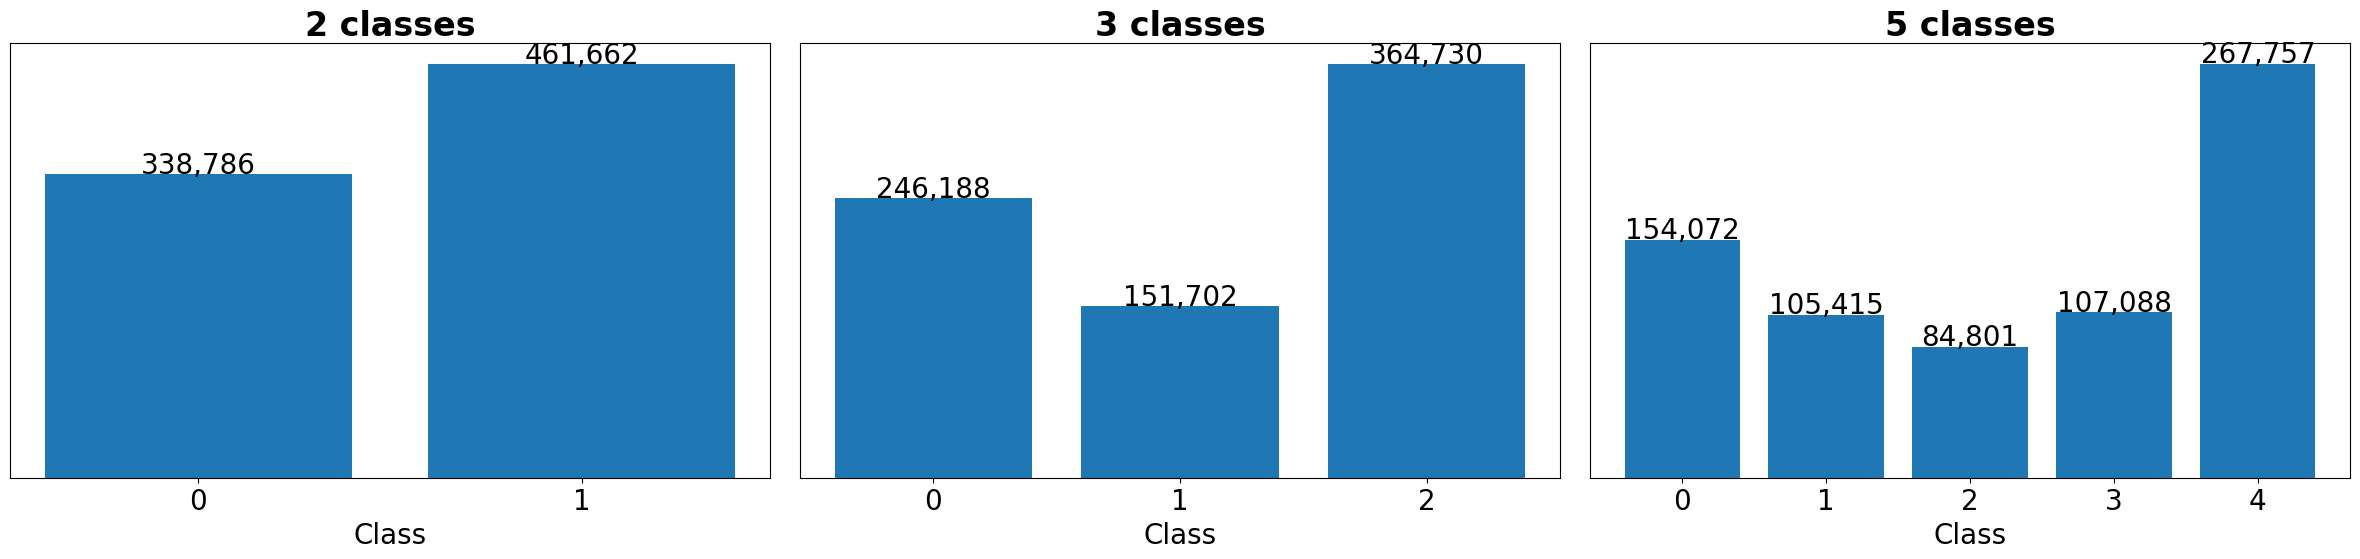

# Raw data experiments

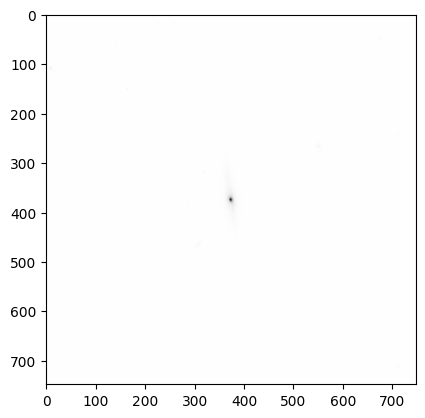

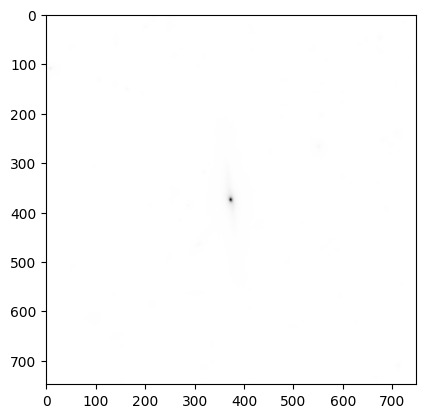

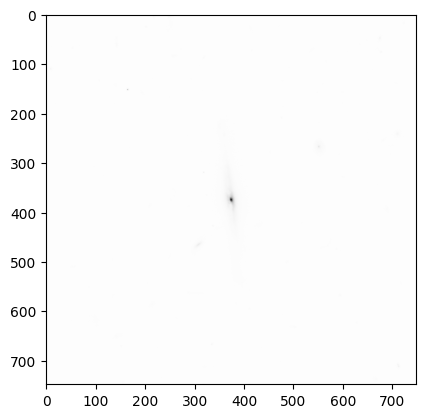

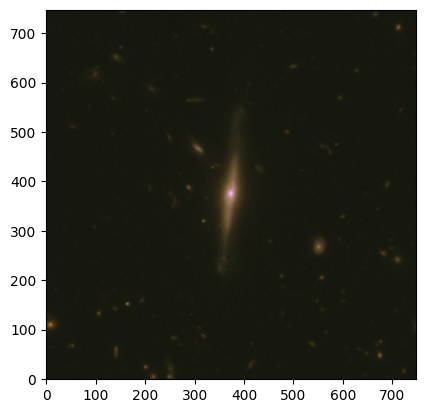

In [ ]:
from astropy.io import fits
from astropy import units as u
from astropy.visualization import make_lupton_rgb
from astropy.nddata.utils import Cutout2D
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import zoom
import pandas as pd
from PIL import Image
from reproject.mosaicking import find_optimal_celestial_wcs
from reproject import reproject_exact

parameters = pd.read_csv("./GZC_Images_Raw/test.cat", sep=" ", skiprows=7, names=['ra', 'dec', 'a', 'kron', 'theta', 'ellipticity', 'flux'])

def transform(img):
    Q = 4
    a = 0.02
    return np.arcsinh(Q * a * (img - img.min())) / Q

def get_size(ra, dec):
    closest_row = None

    pow1 = np.power(ra - parameters['ra'], 2)
    pow2 = np.power(dec - parameters['dec'], 2)
    dist = np.sqrt(pow1 + pow2)
    min_dist = dist.min()
    loc = np.where(dist == min_dist)[0][0]

    closest_row = parameters.iloc[loc]

    return round(2.5 * closest_row['a'] * closest_row['kron'] * (abs(np.sin(closest_row['theta'] * 0.0174533)) + (1 - closest_row['ellipticity']) * abs(np.cos(closest_row['theta'] * 0.0174533))))


def get_image(band, position, size):
    path = f"./GZC_Images_Raw/hlsp_candels_hst_wfc3_cos-tot_f{band}w_v1.0_drz.fits" \
        if band in ('125', '160') \
        else f"./GZC_Images_Raw/hlsp_candels_hst_acs_cos-tot_f{band}w_v1.0_drz.fits"
    
    weight_path = f"./GZC_Images_Raw/hlsp_candels_hst_wfc3_cos-tot_f{band}w_v1.0_wht.fits" \
        if band in ('125', '160') \
        else f"./GZC_Images_Raw/hlsp_candels_hst_acs_cos-tot_f{band}w_v1.0_wht.fits"

    with fits.open(path) as hlu, fits.open(weight_path) as weight_hlu:
        data = hlu[0].data
        header = hlu[0].header

        weight_data = weight_hlu[0].data

        weighted_data = data

        if band in ('125', '160'):
            header['CTYPE1'] = header['CTYPE1'] + '-SIP'
            header['CTYPE2'] = header['CTYPE2'] + '-SIP'

        wcs = WCS(header)

        scale = 0.06 #if band in ('125', '160') else 0.03
        cutout = Cutout2D(weighted_data, wcs.wcs_world2pix(position.ra.deg, position.dec.deg, 1), u.Quantity(size * scale, u.arcsec), wcs=wcs).data
        if band == '814':
            cutout = zoom(cutout, (0.5, 0.5))

        return cutout


position = SkyCoord(150.06773,2.1937409, frame='icrs', unit='deg')
size = max(128, get_size(position.ra.deg, position.dec.deg))


img = np.empty((size, size, 3))


# average = (f125 + f160 + f814) / 3

f160 = get_image('160', position, size)
f125 = get_image('125', position, size)
f814 = get_image('814', position, size)

average = (np.nanmean(f125) + np.nanmean(f160) + np.nanmean(f814)) / 3

f160_transformed = f160
f125_transformed = f125
f814_transformed = f814

plt.imshow(f125_transformed, cmap = 'Greys')
plt.show()

plt.imshow(f160_transformed, cmap = 'Greys')
plt.show()

plt.imshow(f814_transformed, cmap = 'Greys')
plt.show()

def normalize(img):
    return (img - img.min()) / (img.max() - img.min())

img[:, :, 0] = normalize(transform(f160_transformed / average) )
img[:, :, 1] = normalize(transform(f125_transformed / average) )
img[:, :, 2] = normalize(transform(f814_transformed / average) )

# I = (f125 + f160 + f814) / 3

# img[:, :, 0] = f160 * transform(I) / I
# img[:, :, 1] = f125 * transform(I) / I
# img[:, :, 2] = f814 * transform(I) / I

# img[:, :, 0] = img[:, :, 0] * 0.75
img[:, :, 1] = img[:, :, 1] * 0.75

plt.imshow(img, origin="lower")
plt.show()

Image.fromarray(np.uint8(img * 255)).resize((424, 424)).save("elliptical_128_original_z_001.jpg")


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


0.08625309 0.08847359 0.02292064
[[-11.492078     2.1121151    4.516169   ...   7.310811    -2.7060926
   -5.1497283 ]
 [  9.595494    10.246997    -0.17316695 ...   3.911872    -3.082629
    1.4541035 ]
 [  8.069432     9.357576   -18.984665   ... -12.398533    -2.9218216
   -6.9143987 ]
 ...
 [ -7.9627767  -10.719105   -16.428219   ...   0.8570929    5.4931555
   -9.186302  ]
 [  2.730968    13.288855    16.041487   ...   9.614147     9.093278
  -11.306286  ]
 [  1.6977363   10.192253    15.409519   ...  10.767202    14.872294
   -1.0229985 ]]
[[[-7.000e+00 -2.400e+01 -3.000e+00]
  [ 2.000e+00 -4.000e+00  8.000e+00]
  [ 5.000e+00  3.000e+00  4.000e+00]
  ...
  [ 1.300e+01  4.000e+00  3.000e+00]
  [-1.790e+02  3.500e+01  1.350e+02]
  [ 0.000e+00 -7.000e+00 -7.000e+00]]

 [[ 3.200e+01  1.000e+00 -5.000e+00]
  [ 1.100e+01  1.200e+01  6.000e+00]
  [ 1.000e+00 -2.000e+00  0.000e+00]
  ...
  [ 3.000e+00  6.000e+00  2.000e+00]
  [ 1.760e+02 -8.100e+01 -1.040e+02]
  [ 0.000e+00  5.000e+00  0

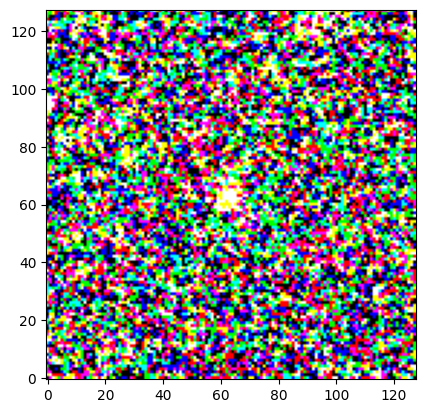

In [46]:
def ln_norm(img):
    return np.log10(img - img.min()) / np.log10(img.max() - img.min())

f160 = get_image('160', position, size)
f125 = get_image('125', position, size)
f814 = get_image('814', position, size)

print(f160.max(), f125.max(), f814.max())

mean= (f160 + f125 + f814) /3.0

scaledMean = (255 / np.arcsinh( (0.088-0.001)/4)) * np.arcsinh((mean-0.001) /4)
scale = scaledMean/mean

print(scaledMean)

img[:, :, 0] = (f160 * scale).astype(int)
img[:, :, 1] = (f125 * scale).astype(int)
img[:, :, 2] = (f814 * scale).astype(int)

print(img)

# I = (f160 + f125 + f814) / 3
# img[:, :, 0] = ln_norm(f160)
# img[:, :, 1] = ln_norm(f125)
# img[:, :, 2] = ln_norm(f814)
plt.imshow(img, origin="lower")
plt.show()